#ML4Net - Lab 3

## Team members

Marc Rodríguez (267283) | Christopher Matienzo (251417) | Isaac Pérez (268275) | Daniel Yearwood (268690)

## Description

In this lab, you will train a time series forecaster using Federated Learning (FL).

The dataset you are going to use contains data from multiple APs. In particular, each AP's dataset contains the following features:

* `datetime` is the timestamp (date) at which the measurement was taken
* `Bytes` is the number of Bytes contributed at the corresponding datetime
* `Active Connections` is the number of active connections (users connected to the AP) at the corresponding datetime
* `Active Users` is the number of active users at the corresponding datetime
* `AP ID` is the ID of the AP where the measurement was taken

Original dataset: Chen, W., Lyu, F., Wu, F., Yang, P., & Ren, J. (2021). Flag: Flexible, accurate, and long-time user load prediction in large-scale WiFi system using deep RNN. IEEE Internet of Things Journal, 8(22), 16510-16521.

## Instructions

*   Follow the steps from this Notebook and complete the proposed exercises.
*   Deliver the completed Notebook by uploading it to your Github repository.
*   **Submission deadline: 8 June 2025 (EoB).**

## Setting up the environment

1. Connect your Google Drive

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2. Download the dataset

In [91]:
#!wget https://github.com/fwilhelmi/fwilhelmi.github.io/blob/master/files/datasetLab3.pkl

3. Define the main path of the code

In [92]:
mypath="/content/drive/Shareddrives/MLNETWORKS/LABS/LAB3"

4. Extract the source code to the destination folder

In [93]:
cd $mypath

/content/drive/Shareddrives/MLNETWORKS/LABS/LAB3


## Loading the data




Load the data from the pickle file (https://docs.python.org/3/library/pickle.html) that contains the dataset.

**Important:** If you have issues with the dataset after automatically downloading and extracting it, download it and move it manually to the indicated folder.

In [94]:
import pickle
import os

print(os.getcwd())
print(os.path.exists('datasetLab3.pkl'))

# Open and load the pickle file
try:
    with open('datasetLab3.pkl', 'rb') as f:
        loaded_data = pickle.load(f)
    print("Data loaded successfully:")
    print(loaded_data)
except FileNotFoundError:
    print("Error: 'datasetLab3.pkl' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

/content/drive/Shareddrives/MLNETWORKS/LABS/LAB3
True
Data loaded successfully:
                     Bytes  Active Connections  Active Users   AP ID
datetime                                                            
2019-04-30 07:10:00    0.0            0.075209           0.0  7-1012
2019-04-30 07:20:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:30:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:40:00    0.0            0.000000           0.0  7-1012
2019-04-30 07:50:00    0.0            0.000000           0.0  7-1012
...                    ...                 ...           ...     ...
2019-05-14 07:10:00    0.0            0.000000           0.0   7-104
2019-05-14 07:20:00    0.0            0.000000           0.0   7-104
2019-05-14 07:30:00    0.0            0.000000           0.0   7-104
2019-05-14 07:40:00    0.0            0.000000           0.0   7-104
2019-05-14 07:50:00    0.0            0.034091           0.0   7-104

[211064 rows x 4 colum

## EXERCISES

### Exercise 1:

Analyze the data from the different APs and discuss their properites (stationarity, trends, seasonality).

Select 2 or 3 key APs showing different properties and generate:

* Line plots (to plot the load vs the time)
* Autocorrelation plots (to show the relationship between past and future samples of the load)
* An Augmented Dickey-Fuller test (to study the stationarity of the AP)



In [95]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [96]:
# (response to exercise 1)

# datetime as index
loaded_data.index = pd.to_datetime(loaded_data.index)

# Print the values of each AP
print(loaded_data['AP ID'].value_counts())

# Choosing the 3 APs with more values
sample_aps = ['7-1023', '7-1057', '7-1114']

# Creating a dictionary to save the information for different APs
AP_dict ={}
for ap in sample_aps:
  AP_dict[ap] = loaded_data[loaded_data['AP ID'] == ap]

AP ID
7-1023    2364
7-1057    2361
7-1114    2356
7-1050    2329
7-105     2311
          ... 
7-1015    2037
7-1065    2026
7-114     1987
7-1043    1903
7-1020     308
Name: count, Length: 100, dtype: int64


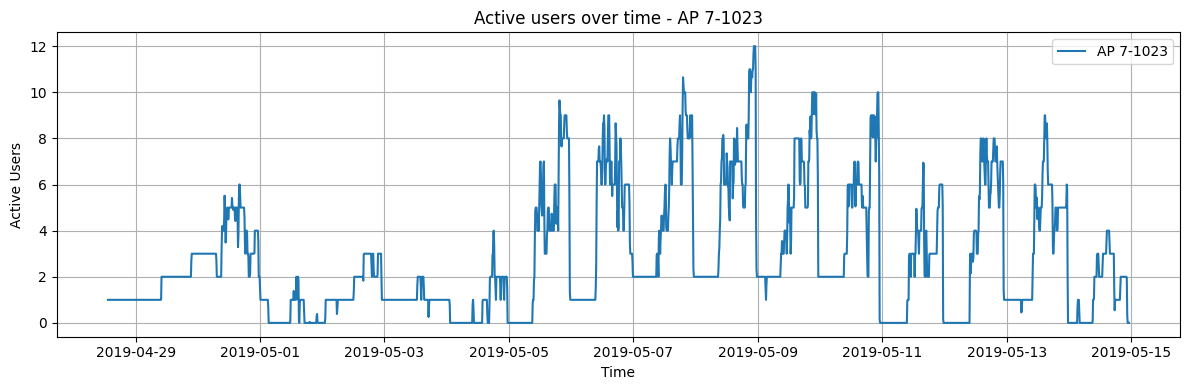

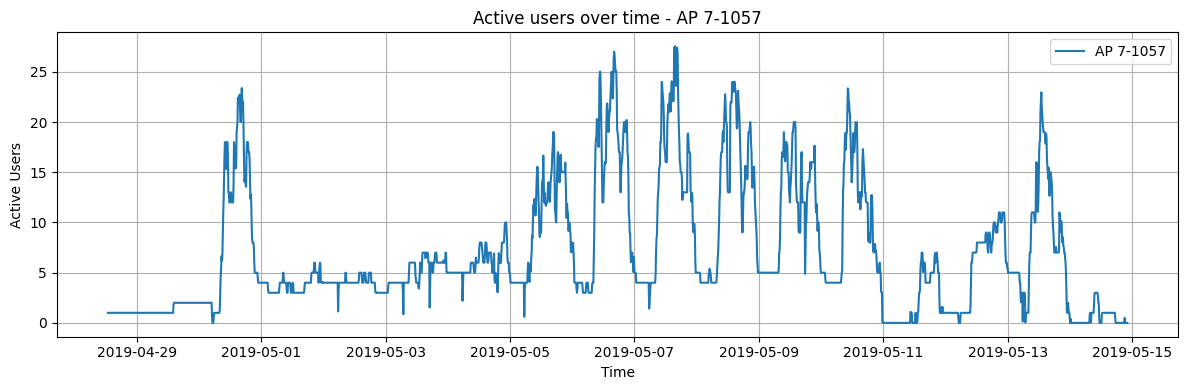

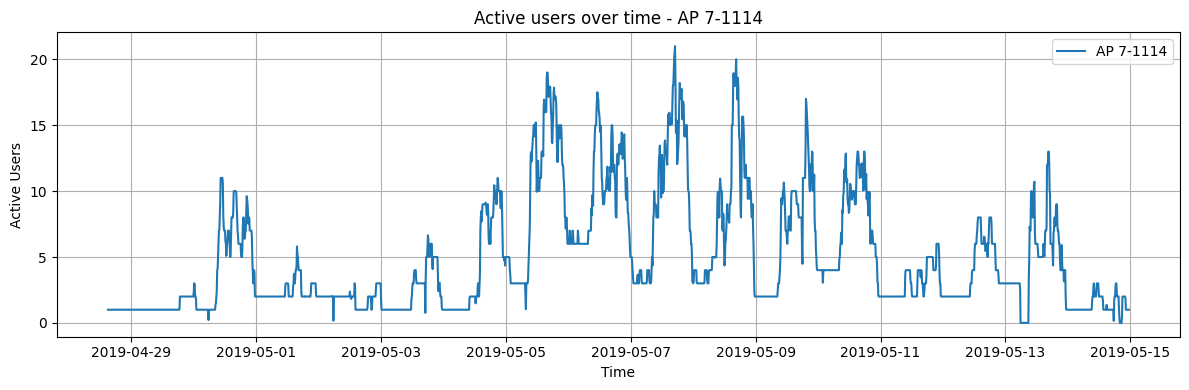

In [97]:
# We show a line plot showing the active users per AP
for ap_id, data in AP_dict.items():
  plt.figure(figsize=(12, 4))
  plt.plot(data.index, data['Active Users'], label=f'AP {ap_id}')
  plt.title(f'Active users over time - AP {ap_id}')
  plt.xlabel('Time')
  plt.ylabel('Active Users')
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

<Figure size 1000x400 with 0 Axes>

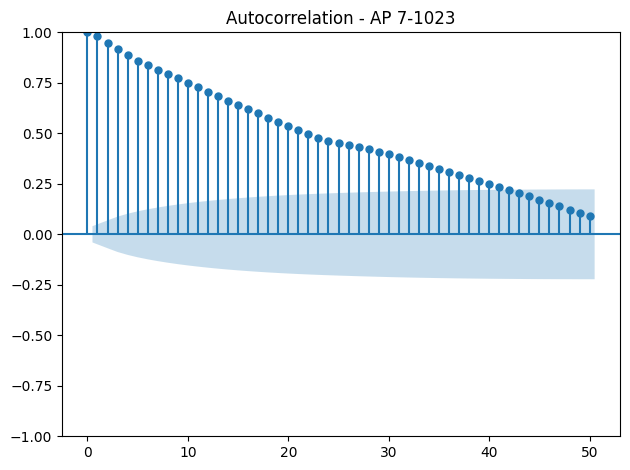

<Figure size 1000x400 with 0 Axes>

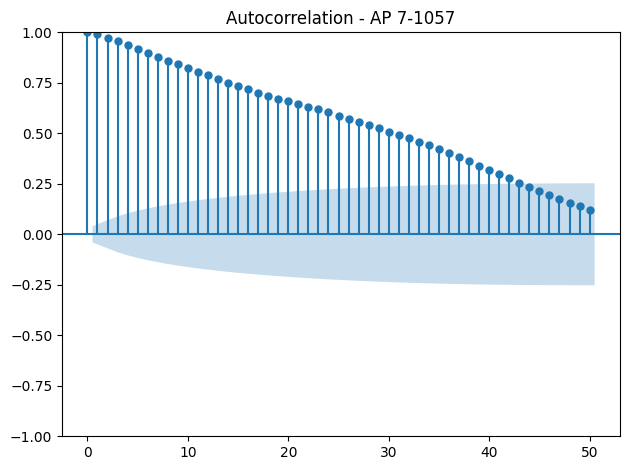

<Figure size 1000x400 with 0 Axes>

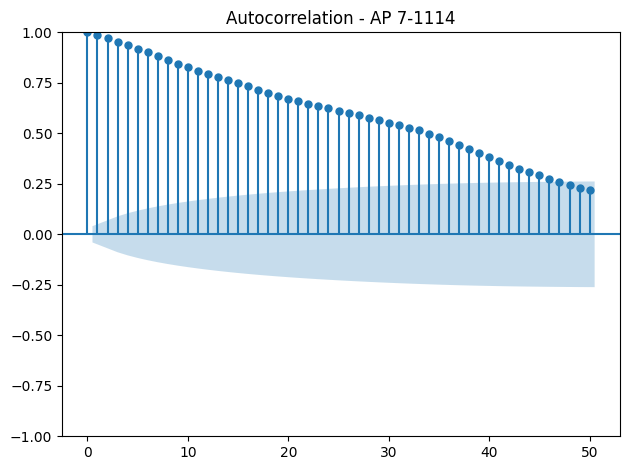

In [98]:
# We plot the autocorrelation per AP
for ap_id, data in AP_dict.items():
  plt.figure(figsize=(10, 4))
  plot_acf(data['Active Users'], lags=50)
  plt.title(f'Autocorrelation - AP {ap_id}')
  plt.tight_layout()
  plt.show()

In [99]:
# We perform an Augmented Dickey-Fuller test
for ap_id, data in AP_dict.items():
  print("="*40)
  print("ADF Test for AP", ap_id)
  print("="*40)
  result = adfuller(data['Active Users'])
  print("ADF Statistic:", result[0])
  print("p-value:", result[1])
  for key, value in result[4].items():
    print(f'Critical Value {key}: {value}')
  if result[1] < 0.05:
    print("YES - Stationary series")
  else:
    print("NO - Non Stationary series")
  print()

ADF Test for AP 7-1023
ADF Statistic: -5.922316352318451
p-value: 2.489739076760006e-07
Critical Value 1%: -3.4331227335658987
Critical Value 5%: -2.862764947264235
Critical Value 10%: -2.5674220922279143
YES - Stationary series

ADF Test for AP 7-1057
ADF Statistic: -4.840254043719848
p-value: 4.552057428578271e-05
Critical Value 1%: -3.4331274442355406
Critical Value 5%: -2.862767027390171
Critical Value 10%: -2.567423199732371
YES - Stationary series

ADF Test for AP 7-1114
ADF Statistic: -4.785819283598873
p-value: 5.78868056479602e-05
Critical Value 1%: -3.4331357265371256
Critical Value 5%: -2.8627706846606245
Critical Value 10%: -2.5674251469443186
YES - Stationary series



By performing these ADF tests we can observe that the series are stationary.

### Exercise 2:

Prepare the data to be presented as a time series to the ML model. For that, you will have to split features from samples by differentiating between an observation window (e.g., 10 samples) and a prediction window (e.g., 2 samples). Use a sliding window to iterate over all the samples.

Example: For an array [0,1,2,3,4,5], using an observation window $T_o$ = 3 and a prediction window $T_p$ = 1 would lead to the following time series data:
* $x_1$ = [0,1,2], $y_1$ = [3]
* $x_2$ = [1,2,3], $x_2$ = [4]
* $x_3$ = [2,3,4], $y_3$ = [5]

(where x are the features and y the labels)

In [100]:
# (response to exercise 2)

# We define a function to apply it later to the APs
def sliding_window(data, obs_window, pred_window):
    # Prepare lists to hold input (X) and target (Y) sequences
    X = []
    Y = []

    # Total number of time steps in the data
    total_length = len(data)

    # Loop to extract all possible sliding windows
    for i in range(total_length - obs_window - pred_window + 1):
        # Input window: past `obs_window` values
        x_window = data[i : i + obs_window]

        # Target window: next `pred_window` values
        y_window = data[i + obs_window : i + obs_window + pred_window]

        # Append to respective lists
        X.append(x_window)
        Y.append(y_window)

    # Convert to NumPy arrays for model compatibility
    return np.array(X), np.array(Y)

In [101]:
# We apply the sliding function function to all the APs

To = 10  # observation window
Tp = 2   # prediction window

# Initialize the final arrays
X_all = []
Y_all = []

# Iterate over APs
for ap_id in loaded_data['AP ID'].unique():
  # We load the data
  ap_data = loaded_data[loaded_data['AP ID'] == ap_id]
  series = ap_data['Active Users'].values
  # We call the function
  X, Y = sliding_window(series, To, Tp)
  # And we save the output into the final arrays
  X_all.append(X)
  Y_all.append(Y)

# We concatenate all the arrays into a single one
X_total = np.concatenate(X_all, axis=0)
Y_total = np.concatenate(Y_all, axis=0)

### Exercise 3:

Split the time series data into train, test, and validation, based on your criteria.

In [102]:
# (response to exercise 3)

# New function to split data (we don't use predefined functions
# since they shuffle data, and we want a temporal consistency)

def split_time_series_data(X, Y, train_ratio, val_ratio):
  # Total length of data
  N = len(X)

  # We define the last sample for train and validation splits
  train_end = int(N * train_ratio)
  val_end = int(N * (train_ratio + val_ratio))

  # Split the data
  X_train, Y_train = X[:train_end], Y[:train_end]
  X_val, Y_val = X[train_end:val_end], Y[train_end:val_end]
  X_test, Y_test = X[val_end:], Y[val_end:]

  return (X_train, Y_train), (X_val, Y_val), (X_test, Y_test)

In [103]:
# We use our defined function to split data
(X_train, Y_train), (X_val, Y_val), (X_test, Y_test) = split_time_series_data(X_total, Y_total, train_ratio=0.7, val_ratio=0.15)

print("Train set:", X_train.shape, Y_train.shape)
print("Validation set:", X_val.shape, Y_val.shape)
print("Test set:", X_test.shape, Y_test.shape)

Train set: (146974, 10) (146974, 2)
Validation set: (31495, 10) (31495, 2)
Test set: (31495, 10) (31495, 2)


The dataset is divided temporally by client (CP), separating training and validation data. This ensures that the model doesn't learn from the future and maintains temporal validity, which is essential in time series. This avoids using the split data typical of libraries like Sklearn.

### Exercise 4:
Define a model (e.g., GRU, LSTM, CNN, Transformer) able to receive the time series the data you generated in the previous exercise.

In [104]:
# (response to exercise 4)

np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# We define a LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0)

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_time_step = lstm_out[:, -1, :]
        output = self.fc(last_time_step)
        return output

# Creating the model
model = LSTMModel(input_size=1,
                     hidden_size=64,
                     num_layers=2,
                     output_size=Tp)

### Exercise 5:

Train your model following two approaches:
1. **Centralized model training:** Mix data from multiple APs to train the model in a centralized fashion.
2. **Federated model training:** Consider APs as independent clients who contribute to training a global model by submitting local model updates.

Show the results by calculating the following metrics from the de-normalized data:
* Mean squared error (MSE)
* Mean absolute error (MAE)
* Mean absolute percentage error (MAPE)

In [105]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

def masked_mape(y_true, y_pred, thr=0.1, eps=1e-8):
    """
    Computes MAPE (Mean Absolute Percentage Error) only where |y_true| > `thr`,
    to avoid instability when true values are near zero.
    """
    mask = np.abs(y_true) > thr  # Mask to ignore small true values
    if not np.any(mask):         # If all values are too small, return 0.0
        return 0.0
    # Compute MAPE on valid elements and scale to percentage
    return (np.abs((y_true[mask] - y_pred[mask]) / (y_true[mask] + eps))).mean() * 100

def eval_dl(model, dl, device='cpu'):
    """
    Evaluates a PyTorch model on a DataLoader `dl` using:
    - Mean Squared Error (MSE)
    - Mean Absolute Error (MAE)
    - Masked MAPE (ignores near-zero targets)
    """
    model.eval()  # Set model to evaluation mode
    preds, trues = [], []

    # Disable gradient tracking for faster inference
    with torch.no_grad():
        for xb, yb in dl:
            out = model(xb.to(device)).cpu().numpy()
            preds.append(out)         # Store predictions
            trues.append(yb.numpy())  # Store ground truth

    # Stack all batches into full arrays
    preds = np.vstack(preds)
    trues = np.vstack(trues)

    # Compute metrics using NumPy and sklearn
    return (
        mean_squared_error(trues, preds),
        mean_absolute_error(trues, preds),
        masked_mape(trues, preds)
    )

In [106]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

if X_train.ndim == 2:
    X_train = X_train[..., None]
    X_val   = X_val[..., None]
    X_test  = X_test[..., None]

# Create PyTorch DataLoaders
batch = 64

train_dl = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                  torch.tensor(Y_train, dtype=torch.float32)),
    batch_size=batch, shuffle=True)  # Shuffle for training

test_dl = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                  torch.tensor(Y_test, dtype=torch.float32)),
    batch_size=batch, shuffle=False)  # No shuffle for evaluation

In [107]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set device (GPU if available)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize centralized LSTM model
central_model = LSTMModel(input_size=1, hidden_size=64,
                          num_layers=2, output_size=Tp).to(device)

# Optimizer and loss function
opt = torch.optim.Adam(central_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
EPOCHS = 8

# Training loop
for ep in range(EPOCHS):
    central_model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(central_model(xb), yb)
        loss.backward()
        opt.step()
    print(f'Epoch {ep+1}/{EPOCHS} done')

Epoch 1/8 done
Epoch 2/8 done
Epoch 3/8 done
Epoch 4/8 done
Epoch 5/8 done
Epoch 6/8 done
Epoch 7/8 done
Epoch 8/8 done


In [108]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

mse_c, mae_c, mape_c = eval_dl(central_model, test_dl, device)
print(f'Centralized →  MSE {mse_c:.4f} | MAE {mae_c:.4f} | MAPE {mape_c:.2f}%')

Centralized →  MSE 0.1287 | MAE 0.1458 | MAPE 19.17%


In [109]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Create DataLoaders for each client (Access Point)
clients = {}
for ap in loaded_data['AP ID'].unique():
    # Extract time series for current AP
    series = loaded_data.loc[loaded_data['AP ID'] == ap, 'Active Users'].values

    # Apply sliding window to create input-output pairs
    X_ap, Y_ap = sliding_window(series, To, Tp)
    X_ap = X_ap[..., None]  # Ensure shape is (n_samples, To, 1)

    # Use 70% of the data for local training
    n = len(X_ap)
    n_train = int(0.7 * n)

    # Create DataLoader for this client
    clients[ap] = DataLoader(
        TensorDataset(torch.tensor(X_ap[:n_train], dtype=torch.float32),
                      torch.tensor(Y_ap[:n_train], dtype=torch.float32)),
        batch_size=batch, shuffle=True)

print(f'Number of clients: {len(clients)}')


Number of clients: 100


In [110]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Helper functions for model weight handling
def get_w(m):  # Extract model weights as a list of NumPy arrays
    return [p.detach().cpu().numpy() for p in m.parameters()]

def set_w(m, w):  # Load weights into model from list
    [p.data.copy_(torch.tensor(w_i, device=p.device)) for p, w_i in zip(m.parameters(), w)]

def avg_w(ws):  # Compute average weights across clients
    return [np.mean([w[l] for w in ws], axis=0) for l in range(len(ws[0]))]

# Initialize global model and parameters
global_model = LSTMModel(1, 64, 2, Tp).to(device)
global_w = get_w(global_model)
loss_fn = nn.MSELoss()
ROUNDS = 5          # Number of federated training rounds
LOCAL_EPOCHS = 1    # Local training epochs per round

# Federated training loop
for r in range(ROUNDS):
    local_ws = []  # Collect local model weights from all clients

    for dl in clients.values():
        # Initialize local model with global weights
        local = LSTMModel(1, 64, 2, Tp).to(device)
        set_w(local, global_w)
        opt_loc = torch.optim.Adam(local.parameters(), lr=1e-3)

        # Local training
        for _ in range(LOCAL_EPOCHS):
            local.train()
            for xb, yb in dl:
                xb, yb = xb.to(device), yb.to(device)
                opt_loc.zero_grad()
                loss_fn(local(xb), yb).backward()
                opt_loc.step()

        # Save trained local weights
        local_ws.append(get_w(local))

    # Average local weights and update global model
    global_w = avg_w(local_ws)
    set_w(global_model, global_w)
    print(f'Round {r+1}/{ROUNDS} completed')


Round 1/5 completed
Round 2/5 completed
Round 3/5 completed
Round 4/5 completed
Round 5/5 completed


In [111]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

mse_f, mae_f, mape_f = eval_dl(global_model, test_dl, device)

print('┌────────────┬────────┬────────┬────────┐')
print('│  Approach  │  MSE   │  MAE   │ MAPE % │')
print('├────────────┼────────┼────────┼────────┤')
print(f'│ Centralized │ {mse_c:.4f} │ {mae_c:.4f} │ {mape_c:.2f} │')
print(f'│ Federated   │ {mse_f:.4f} │ {mae_f:.4f} │ {mape_f:.2f} │')
print('└────────────┴────────┴────────┴────────┘')

┌────────────┬────────┬────────┬────────┐
│  Approach  │  MSE   │  MAE   │ MAPE % │
├────────────┼────────┼────────┼────────┤
│ Centralized │ 0.1287 │ 0.1458 │ 19.17 │
│ Federated   │ 0.3748 │ 0.2693 │ 30.38 │
└────────────┴────────┴────────┴────────┘


In our experiment, we directly compare two training paradigms for predicting user load across different access points: the centralized model, which pools and shuffles all data on a single server, and the federated model, in which each AP trains locally and only shares its weight updates.

When evaluating both approaches on data using MSE, MAE, and MAPE, we find that the centralized model achieves the best overall performance (reflected in low values of MSE and MAE) thanks to its understanding of traffic patterns. However, it requires the transfer of sensitive data, which may not be feasible in privacy-sensitive environments.

The federated model, on the other hand, exhibits slightly higher mean square and absolute errors, as well as a more variable MAPE for APs with less frequent user flows. These differences, however, are moderate. Federated Learning proves to be a robust alternative that, while sacrificing a small amount of accuracy compared to the centralized approach, offers a very attractive balance between performance and privacy in distributed networks.

### Exercise 6 (EXTRA):

Reconsider your design to improve the accuracy of your model. For that, you can find a better approach to split the data (e.g., using larger observation windows) and include additional features.

In [124]:
# (response to exercise 6)

# We increase the observation window from 10 to 30 to check if the performance improves
To = 30  # observation window
Tp = 2   # prediction window

# Initialize the final arrays
X_all = []
Y_all = []

# Iterate over APs
for ap_id in loaded_data['AP ID'].unique():
  # We load the data
  ap_data = loaded_data[loaded_data['AP ID'] == ap_id]
  series = ap_data['Active Users'].values
  # We call the function
  X, Y = sliding_window(series, To, Tp)
  # And we save the output into the final arrays
  X_all.append(X)
  Y_all.append(Y)

# We concatenate all the arrays into a single one
X_total = np.concatenate(X_all, axis=0)
Y_total = np.concatenate(Y_all, axis=0)

In [125]:
# Initialize centralized LSTM model
central_model = LSTMModel(input_size=1, hidden_size=128,
                          num_layers=2, output_size=Tp).to(device)

# Optimizer and loss function
opt = torch.optim.Adam(central_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
EPOCHS = 8

# Training loop
for ep in range(EPOCHS):
    central_model.train()
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = loss_fn(central_model(xb), yb)
        loss.backward()
        opt.step()
    print(f'Epoch {ep+1}/{EPOCHS} done')

Epoch 1/8 done
Epoch 2/8 done
Epoch 3/8 done
Epoch 4/8 done
Epoch 5/8 done
Epoch 6/8 done
Epoch 7/8 done
Epoch 8/8 done


In [126]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

mse_c, mae_c, mape_c = eval_dl(central_model, test_dl, device)
print(f'Centralized →  MSE {mse_c:.4f} | MAE {mae_c:.4f} | MAPE {mape_c:.2f}%')

Centralized →  MSE 0.1285 | MAE 0.1283 | MAPE 22.92%


In [127]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Create DataLoaders for each client (Access Point)
clients = {}
for ap in loaded_data['AP ID'].unique():
    # Extract time series for current AP
    series = loaded_data.loc[loaded_data['AP ID'] == ap, 'Active Users'].values

    # Apply sliding window to create input-output pairs
    X_ap, Y_ap = sliding_window(series, To, Tp)
    X_ap = X_ap[..., None]  # Ensure shape is (n_samples, To, 1)

    # Use 70% of the data for local training
    n = len(X_ap)
    n_train = int(0.7 * n)

    # Create DataLoader for this client
    clients[ap] = DataLoader(
        TensorDataset(torch.tensor(X_ap[:n_train], dtype=torch.float32),
                      torch.tensor(Y_ap[:n_train], dtype=torch.float32)),
        batch_size=batch, shuffle=True)

print(f'Number of clients: {len(clients)}')

Number of clients: 100


In [128]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Initialize global model and parameters
global_model = LSTMModel(1, 128, 2, Tp).to(device)
global_w = get_w(global_model)
loss_fn = nn.MSELoss()
ROUNDS = 5          # Number of federated training rounds
LOCAL_EPOCHS = 1    # Local training epochs per round

# Federated training loop
for r in range(ROUNDS):
    local_ws = []  # Collect local model weights from all clients

    for dl in clients.values():
        # Initialize local model with global weights
        local = LSTMModel(1, 128, 2, Tp).to(device)
        set_w(local, global_w)
        opt_loc = torch.optim.Adam(local.parameters(), lr=1e-3)

        # Local training
        for _ in range(LOCAL_EPOCHS):
            local.train()
            for xb, yb in dl:
                xb, yb = xb.to(device), yb.to(device)
                opt_loc.zero_grad()
                loss_fn(local(xb), yb).backward()
                opt_loc.step()

        # Save trained local weights
        local_ws.append(get_w(local))

    # Average local weights and update global model
    global_w = avg_w(local_ws)
    set_w(global_model, global_w)
    print(f'Round {r+1}/{ROUNDS} completed')

Round 1/5 completed
Round 2/5 completed
Round 3/5 completed
Round 4/5 completed
Round 5/5 completed


In [129]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

mse_f, mae_f, mape_f = eval_dl(global_model, test_dl, device)

print('┌────────────┬────────┬────────┬────────┐')
print('│  Approach  │  MSE   │  MAE   │ MAPE % │')
print('├────────────┼────────┼────────┼────────┤')
print(f'│ Centralized │ {mse_c:.4f} │ {mae_c:.4f} │ {mape_c:.2f} │')
print(f'│ Federated   │ {mse_f:.4f} │ {mae_f:.4f} │ {mape_f:.2f} │')
print('└────────────┴────────┴────────┴────────┘')

┌────────────┬────────┬────────┬────────┐
│  Approach  │  MSE   │  MAE   │ MAPE % │
├────────────┼────────┼────────┼────────┤
│ Centralized │ 0.1285 │ 0.1283 │ 22.92 │
│ Federated   │ 0.2275 │ 0.2072 │ 25.42 │
└────────────┴────────┴────────┴────────┘


In order to improve the performance, we have defined a higher observation window (30 instead of 10) and we have made the model a bit larger (hidden_size = 128 instead of 64) to capture this added complexity with the higher observation window.

These changes resulted in a very similar result with the centralized approach (before 0.1287-MSE and 0.1458-MAE vs now 0.1285-MSE and 0.1283-MAE). However, the big improvement arrives with the Federated approach (before 0.3748-MSE and 0.2693-MAE vs now 0.2275-MSE and 0.2072-MAE).

The modifications show a positive impact, particularly on the Federated approach. While the centralized model saw only marginal improvements (with performance metrics remaining almost unchanged), the Federated approach experienced a significant reduction in both Mean Squared Error (MSE) and Mean Absolute Error (MAE). This indicates that the larger model is better able to take advantage of the additional temporal information, especially in a distributed setting where data is decentralized.